# Credit Card Fraud Detection - EDA, Feature Engineering & Model Comparison

In [37]:
# setup - imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (precision_recall_curve, average_precision_score, roc_auc_score, classification_report, confusion_matrix,precision_score,recall_score,f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# #optional models
# try:
#     import xgboost as xgb
# except Exception as e:
#     xgb = None
#     print("XGBoost not available :",e)
# try:
#     import lightgbm as lgb
# except Exception as e:
#     lgb = None
#     print("LightGBM not available :",e)
import joblib
print("setup complete")

setup complete


In [7]:
# 1. LOAD DATA
DATA_PATH = 'archive/creditcard.csv'
assert os.path.exists(DATA_PATH), f"Data file not found at {DATA_PATH} . please place creditcard.csv next to the notebook"
df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Row, Columns: (284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

 Missing Values (top 20): 
 Time      0
V16       0
Amount    0
V28       0
V27       0
V26       0
V25       0
V24       0
V23       0
V22       0
V21       0
V20       0
V19       0
V18       0
V17       0
V15       0
V1        0
V14       0
V13       0
V12       0
dtype: int64

 target distribution: 
Class
0    284315
1       492
Name: count, dtype: int64
fraud ratio: 0.001727485630620034


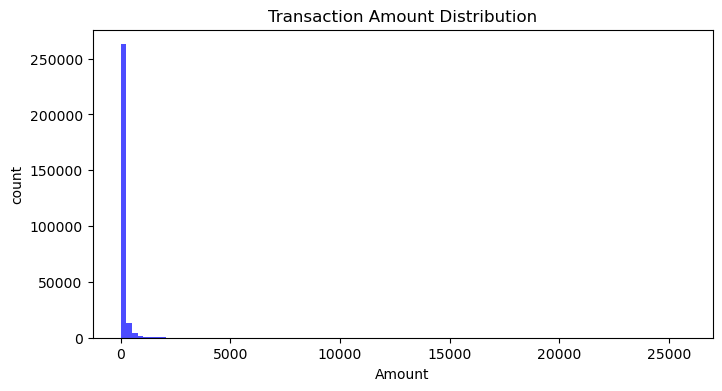

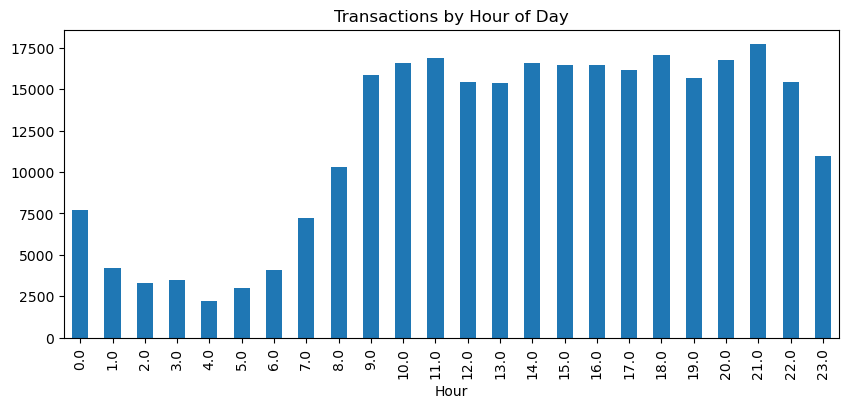

In [10]:
#2. quick EDA
print("Row, Columns:",df.shape)
print(df.dtypes)
print('\n Missing Values (top 20): \n',df.isnull().sum().sort_values(ascending=False).head(20))
target_col = 'Class'
print("\n target distribution: ")
print(df[target_col].value_counts())
print("fraud ratio:", df[target_col].mean())

#amount distribution
plt.figure(figsize=(8,4))
plt.hist(df['Amount'], bins=100, color='blue', alpha=0.7)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('count')
plt.show()

#time based overview
if 'Time' in df.columns:
    df['Hour']= (df['Time'] // 3600) % 24
    plt.figure(figsize=(10,4))
    df.groupby('Hour').size().plot(kind='bar')
    plt.title('Transactions by Hour of Day')
    plt.show()

Data Analysis

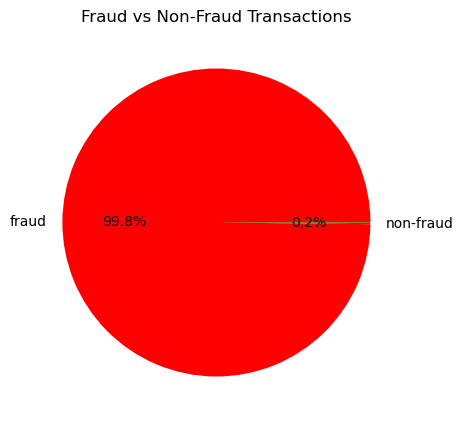

In [14]:
# pie chart
plt.figure(figsize=(5,5))
plt.pie(df['Class'].value_counts(), labels=["fraud","non-fraud"],autopct='%1.1f%%', colors=['red','green'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

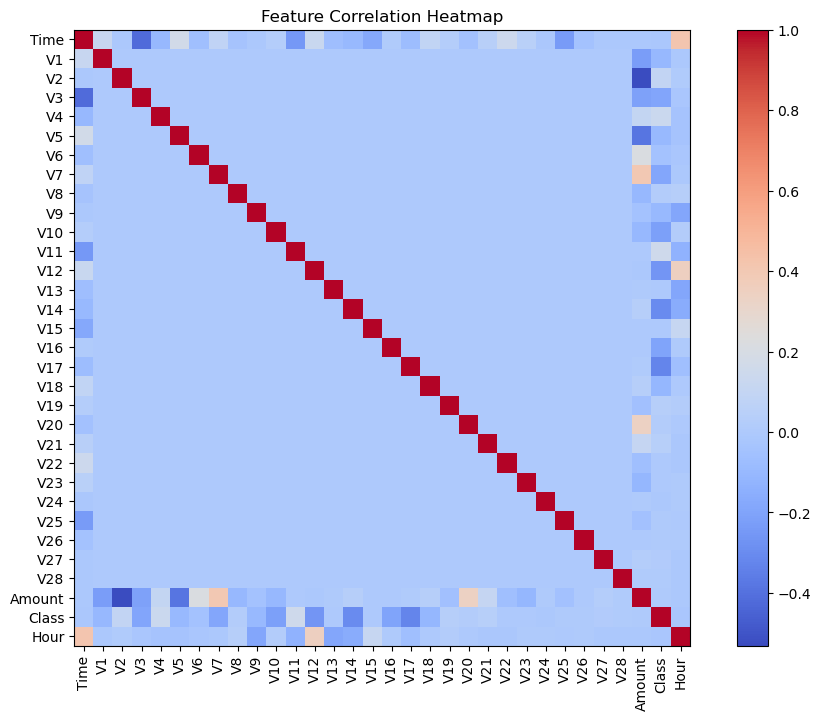

In [15]:
#corelation heatmap
plt.figure(figsize=(12,8))
corr = df.corr()
plt.imshow(corr, cmap = 'coolwarm', interpolation = 'nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns, rotation = 90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title('Feature Correlation Heatmap')
plt.show()

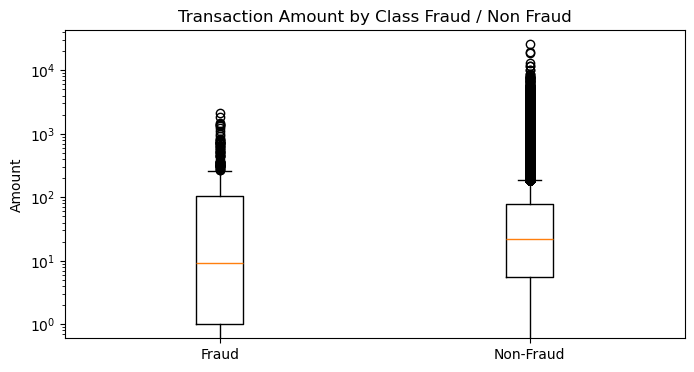

In [18]:
# Fraud vs Non-Fraud Amount
plt.figure(figsize=(8,4))
amount_nonfraud = df[df['Class']==0]['Amount']
amount_fraud = df[df['Class']==1]['Amount']
plt.boxplot([amount_fraud, amount_nonfraud],labels=['Fraud','Non-Fraud'])
plt.yscale('log')
plt.ylabel('Amount')
plt.title('Transaction Amount by Class Fraud / Non Fraud') 
plt.show()

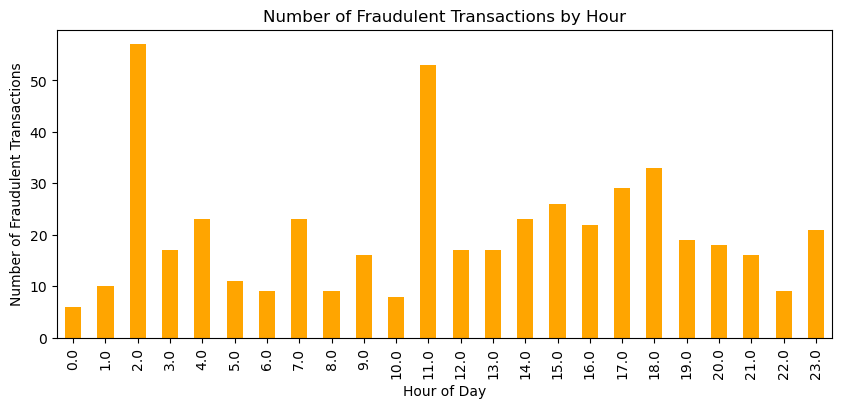

In [19]:
# hourly fraud
hourly = df.groupby('Hour')['Class'].sum()
plt.figure(figsize=(10,4))
hourly.plot(kind='bar', color='orange')
plt.title('Number of Fraudulent Transactions by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

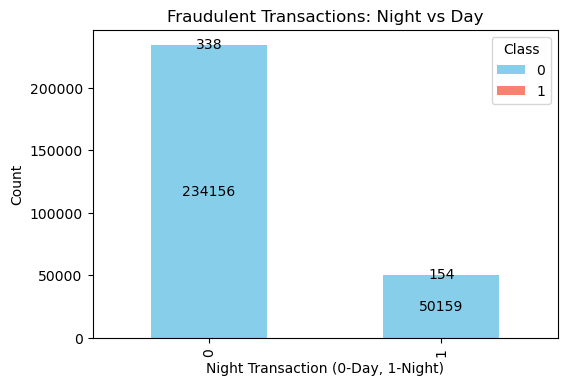

In [23]:
# Night vs Day Fraud
df['is_night'] = df['Hour'].isin([22,23,0,1,2,3,4,5]).astype(int)

night_fraud = df.groupby(['is_night','Class']).size().unstack(fill_value=0)
ax = night_fraud.plot(kind='bar', stacked=True, color=['skyblue','salmon'], figsize=(6,4))
plt.xlabel('Night Transaction (0-Day, 1-Night)')
plt.ylabel('Count')
plt.title('Fraudulent Transactions: Night vs Day')
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')
plt.show()

Preparing Data for Model Creation

In [24]:
#3. Feature Engineering (basic)
# we will create a few strainghtforward features that often helpp:
# - log_amount
# - amount_to_mean_ration(global mean)
# - is_high_amount (amount above 99th percentile)
df_fe = df.copy()
df_fe['log_amount'] = np.log(df_fe['Amount'] + 1)  # Adding 1 to avoid log(0)
global_mean = df_fe['Amount'].mean()
df_fe['amount_to_mean_ratio'] = df_fe['Amount'] / (global_mean + 1e-9)
p99 = df_fe['Amount'].quantile(0.99)
df_fe['is_high_amount'] = (df_fe['Amount'] > p99).astype(int)

#Hour/night
if 'Hour' in df_fe.columns:
    df_fe['is_night'] = df_fe['Hour'].isin([0,1,2,3,4,5,22,23]).astype(int)
else:
    df_fe['is_night'] = 0  # default to 0 if Hour not available                 

#Drop columns we don't want to feed directly (Time kept only for reference, not used in modeling)
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col].values

print("Feature engineering complete. X shape:", X.shape)


Feature engineering complete. X shape: (284807, 35)


In [26]:
# 4. Train/Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train: ", X_train.shape, "Test: ", X_test.shape)

#Scaling numeric features
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
scalar = RobustScaler()
scalar.fit(X_train[numeric_features])

def prop(X_df):
    Xc = X_df.copy()
    Xc[numeric_features] = scalar.transform(Xc[numeric_features])
    #drop time column to avoid leakage of absolute timestamp ; keep hour if present
    if 'Time' in Xc.columns:
        Xc = Xc.drop(columns = ['Time'])
    return Xc

X_train_proc = prop(X_train)
X_test_proc = prop(X_test)
print("Processed data shapes:", X_train_proc.shape, X_test_proc.shape)



Train:  (227845, 35) Test:  (56962, 35)
Processed data shapes: (227845, 34) (56962, 34)


In [27]:
# 5. Evaluation utilities
def evaluate_model(model, X_test, y_test, thresh = 0.5, show_pr_curve = True):
    # obtain probabilities or scores
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        s = model.decision_function(X_test)
        y_scores = (s- s.min())/(s.max() - s.min() + 1e-9)  # min-max scaling to [0,1]  
    else:
        y_scores = model.predict(X_test)
    y_pred = (y_scores >= thresh).astype(int)
    print('Classification report (threshold={}):'.format(thresh))
    print(classification_report(y_test, y_pred, digits=4))
    ap = average_precision_score(y_test, y_scores)
    roc = roc_auc_score(y_test, y_scores)
    cm = confusion_matrix(y_test, y_pred)
    print('Average Precision (AUPRC):',ap)
    print('ROC AUC:',roc)
    print('Confusion Matrix:\n', cm)
    if show_pr_curve:
        precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
        plt.figure(figsize=(6,4))
        plt.plot(recall, precision, marker='.', label='Model')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title(f'PR curve (AP={ap:.4f})')
        plt.show()
    return {'ap': ap, 'roc': roc, 'scores': y_scores}

In [30]:
# 6. Train Baseline Models
trained_models = {}

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga')
lr.fit(X_train_proc, y_train)
trained_models['Logistic Regression'] = lr
print("Trained Logistic Regression")

#Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',n_jobs=-1, random_state=42)
rf.fit(X_train_proc, y_train)
trained_models['Random Forest'] = rf
print("Trained Random Forest")



Trained Logistic Regression
Trained Random Forest



=== Model: Logistic Regression ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0579    0.9184    0.1090        98

    accuracy                         0.9742     56962
   macro avg     0.5289    0.9463    0.5479     56962
weighted avg     0.9982    0.9742    0.9854     56962

Average Precision (AUPRC): 0.709115029175633
ROC AUC: 0.9698768382564055
Confusion Matrix:
 [[55400  1464]
 [    8    90]]


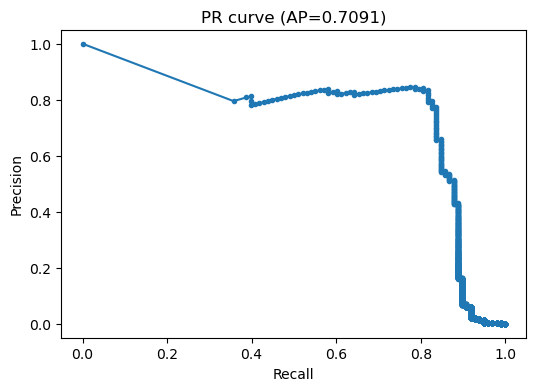


=== Model: Random Forest ===
Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9615    0.7653    0.8523        98

    accuracy                         0.9995     56962
   macro avg     0.9806    0.8826    0.9260     56962
weighted avg     0.9995    0.9995    0.9995     56962

Average Precision (AUPRC): 0.8689747438567735
ROC AUC: 0.9572644864079565
Confusion Matrix:
 [[56861     3]
 [   23    75]]


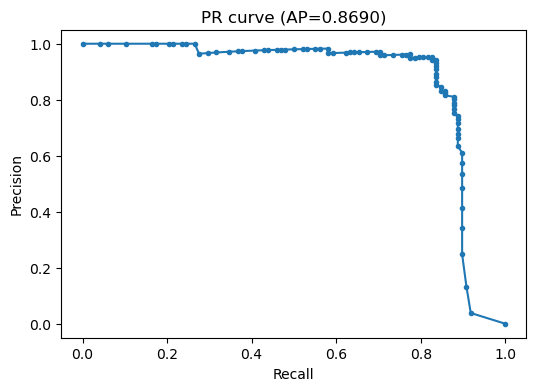

,model,AP,ROC
1,Random Forest,0.868975,0.957264
0,Logistic Regression,0.709115,0.969877


In [33]:
# 7. Evaluate all trained models
results = []
for name, model in trained_models.items():
    print('\n=== Model:',name,'===')
    res = evaluate_model(model, X_test_proc, y_test)
    results.append({'model': name, 'AP': res['ap'], 'ROC': res['roc']})

res_df = pd.DataFrame(results).sort_values('AP', ascending=False)
res_df

In [35]:
#8. Threshold tuning (example using best available model ) and flag extraction
# choose best model based on AP
best_model_name = res_df.iloc[0]['model']
model = trained_models[best_model_name]
print(f"Best model based on AP: {best_model_name}")

#predict scores on test set and compute best threshold based on F1 test(for demonstration)
if hasattr(model, "predict_proba"):
    y_scores = model.predict_proba(X_test_proc)[:,1]
else:
    s = model.decision_function(X_test_proc)
    y_scores = (s - s.min())/(s.max() - s.min() + 1e-9)  # min-max scaling to [0,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
f1_scores = 2*(precision * recall) / (precision + recall + 1e-9)
best_idx = np.nanargmax(f1_scores)
best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
print("Best threshold by F1 on test : ", best_thresh)

#prepare full dataset features and scores
X_all_proc = prop(X)  # process all data with same scaling and feature engineering
if hasattr(model, "predict_proba"):
    all_scores = model.predict_proba(X_all_proc)[:,1]
else:
    s = model.decision_function(X_all_proc)
    all_scores = (s - s.min())/(s.max() - s.min() + 1e-9)  # min-max scaling to [0,1]

df_out = df_fe.copy()
df_out['fraud_score'] = all_scores
df_out['pred_fraud'] = (all_scores >= best_thresh).astype(int)
flagged = df_out[df_out['pred_fraud'] == 1].sort_values('fraud_score', ascending=False)
print('Flagged transactions (top 10):',len(flagged))
flagged.head(20).to_csv('flagged_transactions.csv', index=False)
print("Flagged transactions saved to flagged_transactions.csv")

Best model based on AP: Random Forest
Best threshold by F1 on test :  0.33
Flagged transactions (top 10): 483
Flagged transactions saved to flagged_transactions.csv


In [36]:
# 10.Save the best model for future use
joblib.dump(model, 'best_fraud_model.pkl')
print("Best model saved as best_fraud_model.pkl")

Best model saved as best_fraud_model.pkl
